In [17]:
print('All good')

All good


In [18]:
# To support both python 2 and python 3
from __future__ import division, print_function, unicode_literals

# Common imports 
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "end_to_end_project"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

In [19]:
import subprocess
import seaborn; seaborn.set_style('whitegrid')
from pomegranate import *
import pandas as pd
from sklearn.tree import export_graphviz
from sklearn.preprocessing import LabelEncoder

In [20]:
input_file = "~/Desktop/SI/A1 Chiciudean Vivian/DATA_CV.csv"

Incarcam fisierul csv si filtram datele dupa bunul plac, astfel incat vom retine doar datele care POSIBIL ne vor ajuta

In [21]:
# comma delimited is the default
data = pd.read_csv(input_file, header = 0)
final_data=data.iloc[:,[1,2,3,4,5,6,10,11,16,17,22,23,28,29,34,35,40,41,46,47,52,53,58,59,64,65,70,71,76,77,82,83,88,89,94,95,100,101,106,107,112,113,130,131]]
data_with_exactly_2=final_data.groupby(['IDPAC']).mean()

ids_with_exactly_2=data_with_exactly_2[data_with_exactly_2['NrInt']>=1.5].index.values
ids_with_exactly_2=set(ids_with_exactly_2)
c=np.array(final_data.columns)
c=c.tolist()
final_final=pd.DataFrame(columns=c)
index=0
#ne asiguram ca avem doar pacienti cu mai mult de 2 internari
for i in range(len(final_data.index)):    
    if final_data.values[i][0] in ids_with_exactly_2:
        final_final.loc[index]=final_data.values[i]
        index=index+1

final_data_filtered=final_final

FileNotFoundError: [Errno 2] No such file or directory: '/home/sergiu/Desktop/SI/A1 Chiciudean Vivian/DATA_CV.csv'

Dupa ce am luat datele cu mai mult de 2 internari vom retine doar prima internare, pentru ca putem obtine toate informatiile din acel rand

In [22]:
c=np.array(final_data_filtered.columns)
c=c.tolist()
data=pd.DataFrame(columns=c)
index=0
#din tabelul cu date care are au mai mult de 2 internari, 
#luam datele de la prima internare, astfel incat putem obtine orice informatie din acel rand
for i in range(len(final_data_filtered.index)):    
    if (final_data_filtered['NrInt'][i] == 1) :
        data.loc[index]=final_data_filtered.values[i]
        index=index+1
print(data)

NameError: name 'final_data_filtered' is not defined

In [23]:
data.head()

NameError: name 'data' is not defined

In [24]:
data.describe(include='all')

NameError: name 'data' is not defined

Saving figure attribute_histogram_plots


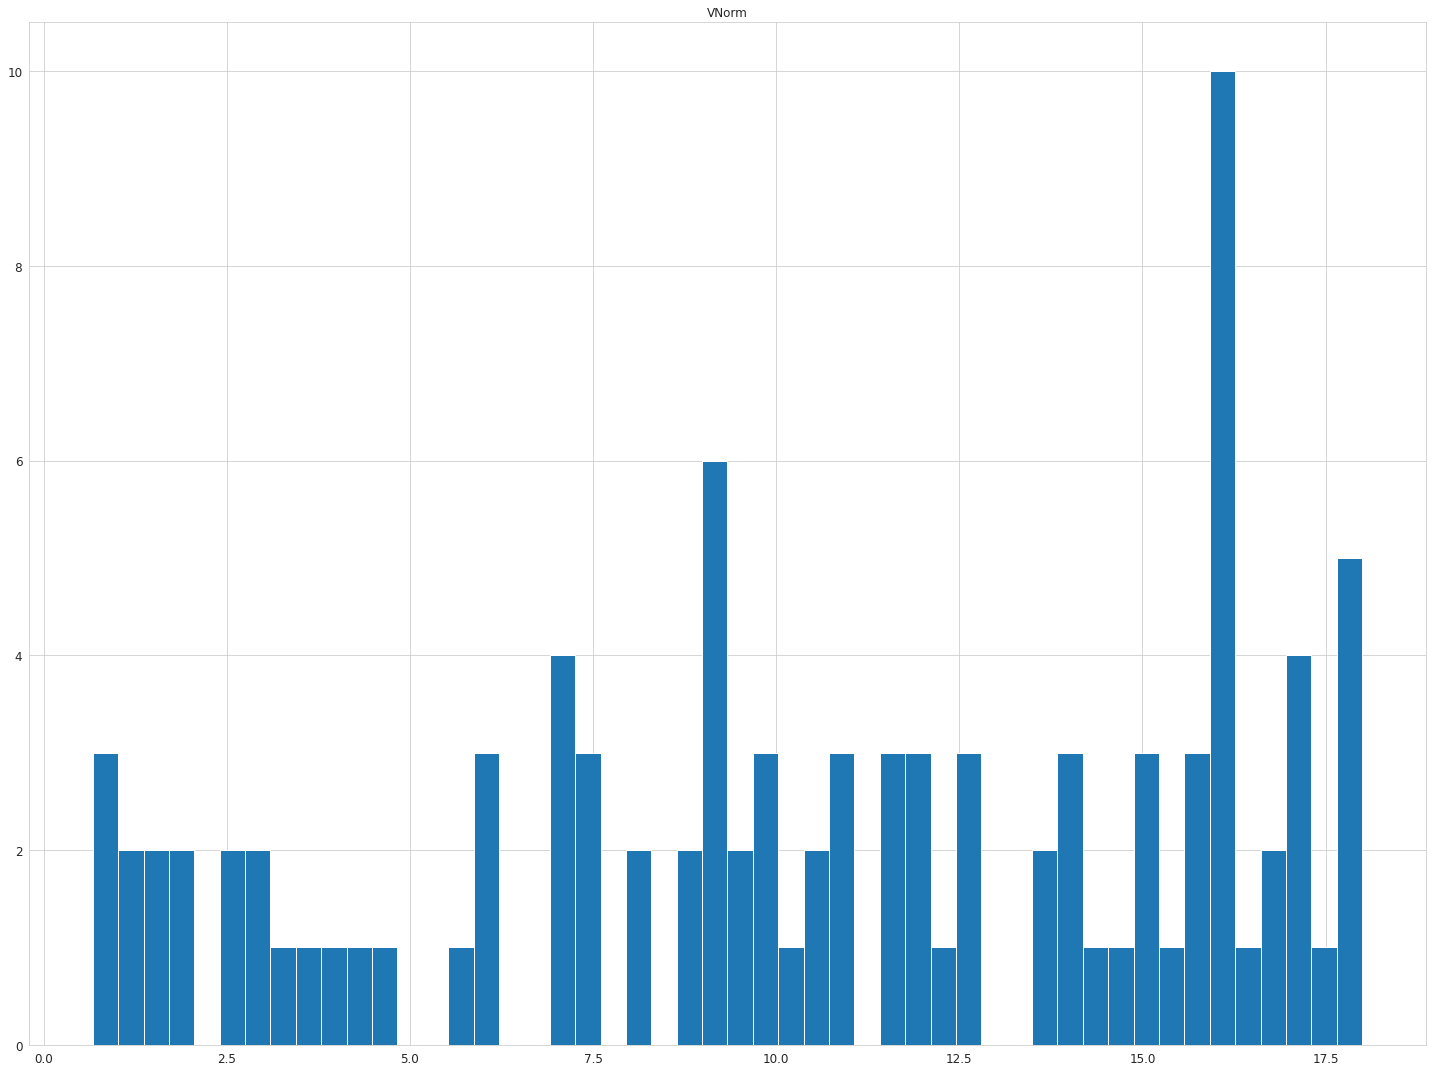

In [9]:
data.hist(bins=50, figsize=(20,15))
save_fig("attribute_histogram_plots")
plt.show()

Encodam datele pentru a putea plota corect

In [10]:
#numerical encoding
le = LabelEncoder()
temp_data= data.drop(data.columns[[0,1,2,3,4,5]],axis=1)
data_l = temp_data.apply(le.fit_transform)
data_l

,SDA,SDA2,SDE,SDE2,VAR,VAR2,HIPO,HIPO2,ANEMIE,ANEMIE2,...,DRE,DRE2,ULCER,ULCER2,BII,BII2,ALTE,ALTE2,ESOFMUC,ESOFMUC2
0,1,1,0,1,1,1,0,0,1,1,...,1,0,0,0,1,2,1,1,2,4
1,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,1,2,0,0,0,1
2,1,1,1,1,1,1,0,1,1,1,...,1,0,0,0,1,2,1,1,2,4
3,0,1,1,1,1,1,1,1,1,1,...,1,0,0,0,1,2,0,1,2,1
4,1,1,1,1,1,1,0,1,1,1,...,1,0,0,0,1,2,1,1,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,1,2,1,1,0,1
93,1,1,0,1,1,1,1,1,1,1,...,1,0,0,0,1,2,1,1,0,4
94,0,1,1,1,1,1,1,1,1,1,...,1,0,0,0,1,2,1,1,2,4
95,1,1,1,1,1,1,0,1,1,1,...,1,0,0,0,1,2,1,1,0,4


In [11]:
data_l.describe(include='all')

,SDA,SDA2,SDE,SDE2,VAR,VAR2,HIPO,HIPO2,ANEMIE,ANEMIE2,...,DRE,DRE2,ULCER,ULCER2,BII,BII2,ALTE,ALTE2,ESOFMUC,ESOFMUC2
count,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.00000,97.000000,97.000000,...,97.000000,97.0,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000
mean,0.762887,0.917526,0.835052,0.948454,0.938144,0.989691,0.752577,0.85567,0.958763,0.989691,...,0.969072,0.0,0.010309,0.020619,0.979381,1.969072,0.814433,0.876289,1.360825,3.072165
std,0.427522,0.276515,0.373062,0.222258,0.242145,0.101535,0.433756,0.35325,0.199871,0.101535,...,0.174022,0.0,0.101535,0.142842,0.142842,0.226090,0.390776,0.330962,0.926301,1.386298
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.000000,0.0,0.000000,0.000000,1.000000,2.000000,1.000000,1.000000,0.000000,1.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.000000,0.0,0.000000,0.000000,1.000000,2.000000,1.000000,1.000000,2.000000,4.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.000000,0.0,0.000000,0.000000,1.000000,2.000000,1.000000,1.000000,2.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.000000,0.0,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,4.000000


Saving figure plots


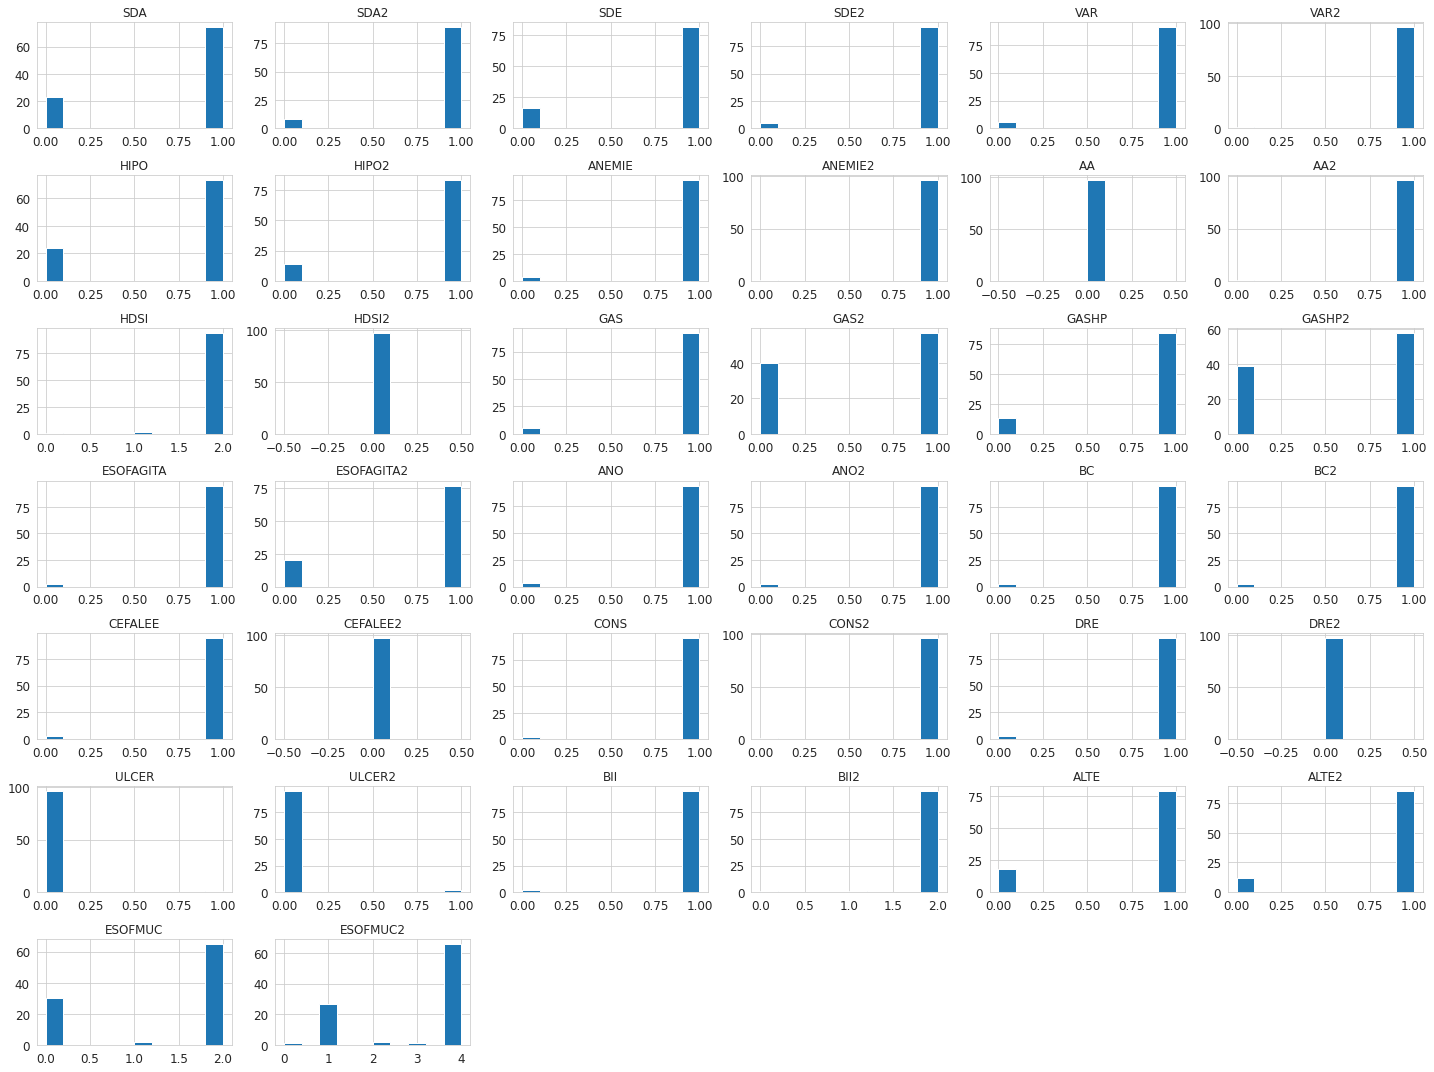

In [12]:
data_l.hist(bins=10, figsize=(20,15))
save_fig("plots")
plt.show()

Facem split in date de test si de training

In [13]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(data_l, test_size=0.2, random_state=42)
print(len(train_set), "train +", len(test_set), "test")

77 train + 20 test


In [14]:
train_set

,SDA,SDA2,SDE,SDE2,VAR,VAR2,HIPO,HIPO2,ANEMIE,ANEMIE2,...,DRE,DRE2,ULCER,ULCER2,BII,BII2,ALTE,ALTE2,ESOFMUC,ESOFMUC2
49,0,1,1,1,1,1,1,1,1,1,...,1,0,0,0,1,2,1,1,1,4
70,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,1,2,0,1,0,4
68,1,1,1,0,1,1,1,1,1,1,...,1,0,0,0,1,2,1,1,2,4
15,0,0,1,1,1,1,1,1,1,1,...,1,0,0,0,1,2,1,1,0,2
39,0,1,1,1,1,1,0,0,1,1,...,1,0,0,0,1,2,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,0,1,1,1,1,1,0,1,1,1,...,1,0,0,0,1,2,1,1,2,4
71,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,1,2,1,1,0,4
14,1,1,1,1,0,1,1,1,1,1,...,1,0,0,0,1,2,1,1,2,4
92,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,1,2,1,1,0,1


In [15]:
test_set

,SDA,SDA2,SDE,SDE2,VAR,VAR2,HIPO,HIPO2,ANEMIE,ANEMIE2,...,DRE,DRE2,ULCER,ULCER2,BII,BII2,ALTE,ALTE2,ESOFMUC,ESOFMUC2
62,1,1,0,1,1,1,1,1,1,1,...,1,0,0,1,1,2,1,1,2,1
40,1,1,1,1,1,1,0,0,1,1,...,1,0,0,0,1,2,1,1,2,1
93,1,1,0,1,1,1,1,1,1,1,...,1,0,0,0,1,2,1,1,0,4
18,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,1,2,1,1,2,4
81,1,1,1,1,1,1,0,1,1,1,...,1,0,0,0,1,2,1,1,2,1
83,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,1,2,0,0,2,4
64,1,1,1,1,0,1,1,1,1,1,...,1,0,0,0,1,2,1,1,0,4
42,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,1,2,0,1,2,4
10,0,0,1,1,1,1,1,1,1,1,...,1,0,0,0,1,2,1,1,2,1
0,1,1,0,1,1,1,0,0,1,1,...,1,0,0,0,1,2,1,1,2,4


# Discover and visualize the data to gain insights

In [16]:
data

,IDPAC,NrInt,Sex,VAn,VLu,VNorm,SDA,SDA2,SDE,SDE2,...,DRE,DRE2,ULCER,ULCER2,BII,BII2,ALTE,ALTE2,ESOFMUC,ESOFMUC2
0,3,1,F,12,6,12.50,NU,NU,DA,NU,...,NU,NU,NU,NU,NU,NU,NU,NU,N,N
1,8,1,F,18,0,18.00,NU,NU,NU,NU,...,NU,NU,NU,NU,NU,NU,DA,DA,E1,E1
2,46,1,F,1,2,1.17,NU,NU,NU,NU,...,NU,NU,NU,NU,NU,NU,NU,NU,N,N
3,117,1,F,16,0,16.00,DA,NU,NU,NU,...,NU,NU,NU,NU,NU,NU,DA,NU,N,E1
4,149,1,M,6,0,6.00,NU,NU,NU,NU,...,NU,NU,NU,NU,NU,NU,NU,NU,N,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,2750,1,F,8,9,8.75,NU,NU,NU,NU,...,NU,NU,NU,NU,NU,NU,NU,NU,E1,E1
93,2756,1,M,10,6,10.50,NU,NU,DA,NU,...,NU,NU,NU,NU,NU,NU,NU,NU,E1,N
94,2780,1,F,4,8,4.67,DA,NU,NU,NU,...,NU,NU,NU,NU,NU,NU,NU,NU,N,N
95,2784,1,F,0,8,0.67,NU,NU,NU,NU,...,NU,NU,NU,NU,NU,NU,NU,NU,E1,N


In [17]:
#data["SDA"].value_counts() / len(data)

Saving figure age against esofmuc


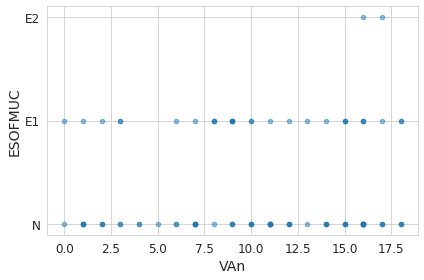

In [18]:
data.plot(kind="scatter", x="VAn", y="ESOFMUC", alpha=0.5)
save_fig("age against esofmuc")

Saving figure age against esofmuc2


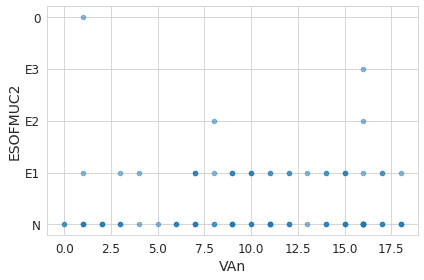

In [19]:
data.plot(kind="scatter", x="VAn", y="ESOFMUC2", alpha=0.5)
save_fig("age against esofmuc2")

Saving figure better_visualization_plot


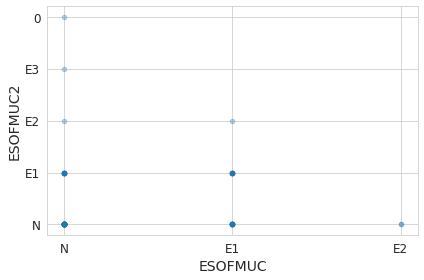

In [20]:
data.plot(kind="scatter", x="ESOFMUC", y="ESOFMUC2", alpha=0.3)
save_fig("better_visualization_plot")

matplotlib: 3.4.1
Saving figure Esofmuc2 against age based on esofmuc also


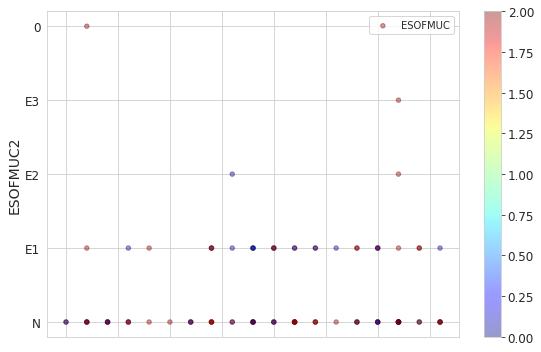

In [21]:
import matplotlib 
print('matplotlib: {}'. format(matplotlib. __version__))
data.plot(kind='scatter',
             x='VAn',
             y='ESOFMUC2',
             alpha=0.4,
             label='ESOFMUC',
             c=data_l['ESOFMUC'],
             cmap=plt.get_cmap('jet'),
             figsize=(8,5),
             colorbar=True)
             #sharex=False)
plt.legend()
save_fig("Esofmuc2 against age based on esofmuc also")

In [22]:
corr_matrix = data_l.corr()

In [23]:
corr_matrix

,SDA,SDA2,SDE,SDE2,VAR,VAR2,HIPO,HIPO2,ANEMIE,ANEMIE2,...,DRE,DRE2,ULCER,ULCER2,BII,BII2,ALTE,ALTE2,ESOFMUC,ESOFMUC2
SDA,1.000000,0.009084,-0.247780,-0.020343,-0.042531,-0.056900,-0.094972,0.046931,-0.115621,-0.056900,...,0.040416,NaN,0.056900,0.080891,-0.080891,-0.076659,-0.079063,0.011384,-0.097351,-0.041131
SDA2,0.009084,1.000000,0.068707,-0.069894,-0.076985,-0.030600,0.001791,-0.123133,0.126300,-0.030600,...,-0.053561,NaN,0.030600,0.043501,-0.043501,-0.041226,0.049691,0.001173,0.036057,0.178732
SDE,-0.247780,0.068707,1.000000,-0.103612,-0.114123,-0.045361,-0.061718,0.054597,0.047527,-0.045361,...,-0.079399,NaN,0.045361,-0.130989,-0.064487,-0.061113,-0.212149,0.001740,-0.067124,0.003115
SDE2,-0.020343,-0.069894,-0.103612,1.000000,-0.059861,0.437798,-0.025620,-0.095745,-0.048348,-0.023793,...,-0.041647,NaN,0.023793,0.033826,-0.033826,-0.032056,0.008655,0.054016,0.141879,-0.089224
VAR,-0.042531,-0.076985,-0.114123,-0.059861,1.000000,-0.026207,0.150298,0.259879,-0.053253,-0.026207,...,-0.045872,NaN,0.026207,0.037257,-0.037257,-0.035308,-0.122568,-0.096480,0.007660,0.044467
VAR2,-0.056900,-0.030600,-0.045361,0.437798,-0.026207,1.000000,-0.058521,-0.041917,-0.021167,-0.010417,...,-0.018233,NaN,0.010417,0.014809,-0.014809,-0.014034,-0.048718,-0.038348,0.150718,-0.068664
HIPO,-0.094972,0.001791,-0.061718,-0.025620,0.150298,-0.058521,1.000000,0.580310,0.001239,-0.058521,...,0.035567,NaN,0.058521,0.083195,-0.083195,-0.078843,-0.212240,-0.070317,-0.086597,0.099296
HIPO2,0.046931,-0.123133,0.054597,-0.095745,0.259879,-0.041917,0.580310,1.000000,0.062360,-0.041917,...,0.096080,NaN,0.041917,0.059591,-0.059591,-0.056473,-0.120581,-0.154314,-0.093862,0.000219
ANEMIE,-0.115621,0.126300,0.047527,-0.048348,-0.053253,-0.021167,0.001239,0.062360,1.000000,0.492125,...,-0.037050,NaN,0.021167,0.030091,-0.030091,-0.028517,0.034373,-0.077924,-0.031322,0.086041
ANEMIE2,-0.056900,-0.030600,-0.045361,-0.023793,-0.026207,-0.010417,-0.058521,-0.041917,0.492125,1.000000,...,-0.018233,NaN,0.010417,0.014809,-0.014809,-0.014034,-0.048718,-0.038348,-0.070792,0.153350


Vedem cat de importante sunt anumite date fata de ce vrem sa prezicem

In [24]:
corr_matrix["ESOFMUC"].sort_values(ascending=False)

ESOFMUC       1.000000
ESOFAGITA2    0.669652
ESOFAGITA     0.214266
VAR2          0.150718
ESOFMUC2      0.149860
SDE2          0.141879
CEFALEE       0.134572
ANO           0.134572
ANO2          0.056813
BC2           0.056813
BC            0.056813
ALTE          0.043017
GAS           0.040686
SDA2          0.036057
VAR           0.007660
DRE           0.005330
GASHP        -0.010156
GAS2         -0.012886
HDSI         -0.025393
ANEMIE       -0.031322
ULCER2       -0.056813
SDE          -0.067124
ANEMIE2      -0.070792
AA2          -0.070792
CONS2        -0.070792
HIPO         -0.086597
GASHP2       -0.089620
HIPO2        -0.093862
BII2         -0.095375
SDA          -0.097351
BII          -0.100640
CONS         -0.100640
ULCER        -0.150718
ALTE2        -0.158681
AA                 NaN
HDSI2              NaN
CEFALEE2           NaN
DRE2               NaN
Name: ESOFMUC, dtype: float64

In [25]:
corr_matrix["ESOFMUC2"].sort_values(ascending=False)

ESOFMUC2      1.000000
SDA2          0.178732
ANEMIE2       0.153350
ESOFMUC       0.149860
GAS           0.147429
HIPO          0.099296
ANEMIE        0.086041
ULCER         0.068664
ALTE2         0.065068
ESOFAGITA     0.060196
BC2           0.060196
BC            0.060196
GAS2          0.059020
ESOFAGITA2    0.045145
VAR           0.044467
ANO           0.009348
SDE           0.003115
HIPO2         0.000219
HDSI         -0.021680
SDA          -0.041131
ULCER2       -0.060196
VAR2         -0.068664
AA2          -0.068664
CONS2        -0.068664
ALTE         -0.071165
SDE2         -0.089224
BII2         -0.092509
ANO2         -0.097615
BII          -0.097615
CONS         -0.097615
DRE          -0.120188
CEFALEE      -0.120188
GASHP        -0.133011
GASHP2       -0.170532
AA                 NaN
HDSI2              NaN
CEFALEE2           NaN
DRE2               NaN
Name: ESOFMUC2, dtype: float64

Selectia atributelor care ne intereseaza

Saving figure scatter_matrix_plot


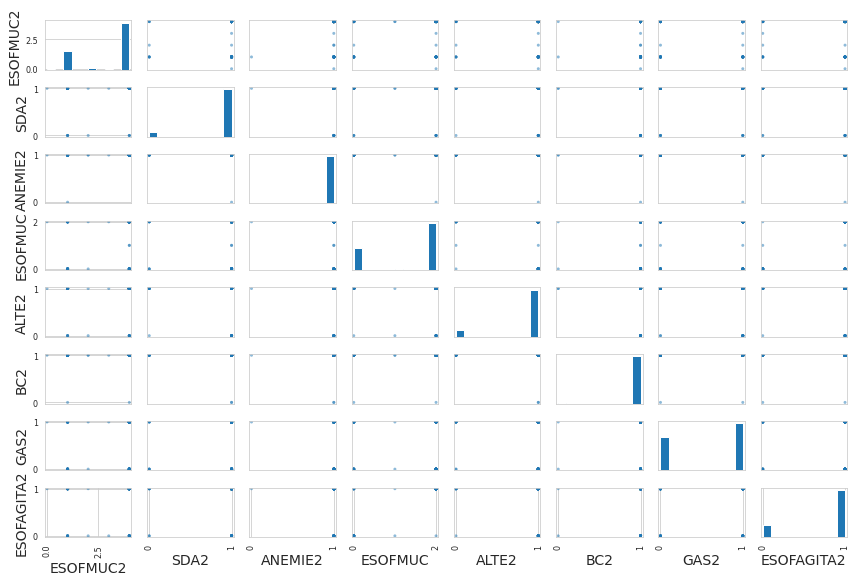

In [26]:
from pandas.plotting import scatter_matrix

attributes = ["ESOFMUC2", "SDA2", "ANEMIE2", "ESOFMUC",
              "ALTE2", "BC2", "GAS2", "ESOFAGITA2"]
scatter_matrix(data_l[attributes], figsize=(12, 8))
save_fig("scatter_matrix_plot")

Facem combinarea atributelor, mai exact vrem sa vedem cine a avut acelasi simptom la ambele consultatii

In [27]:
data_l["SdaAndSda2"]= (data_l["SDA"] * data_l["SDA2"])
data_l["VarAndVar2"]= (data_l["VAR"] * data_l["VAR2"])
data_l["EsofAndEsof2"]= (data_l["ESOFAGITA"] * data_l["ESOFAGITA2"])
data_l["BcAndBc2"]= (data_l["BC"] * data_l["BC2"])
data_l

,SDA,SDA2,SDE,SDE2,VAR,VAR2,HIPO,HIPO2,ANEMIE,ANEMIE2,...,BII,BII2,ALTE,ALTE2,ESOFMUC,ESOFMUC2,SdaAndSda2,VarAndVar2,EsofAndEsof2,BcAndBc2
0,1,1,0,1,1,1,0,0,1,1,...,1,2,1,1,2,4,1,1,1,1
1,1,1,1,1,1,1,1,1,1,1,...,1,2,0,0,0,1,1,1,1,1
2,1,1,1,1,1,1,0,1,1,1,...,1,2,1,1,2,4,1,1,1,1
3,0,1,1,1,1,1,1,1,1,1,...,1,2,0,1,2,1,0,1,1,1
4,1,1,1,1,1,1,0,1,1,1,...,1,2,1,1,2,4,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,1,1,1,1,1,1,1,1,1,1,...,1,2,1,1,0,1,1,1,1,1
93,1,1,0,1,1,1,1,1,1,1,...,1,2,1,1,0,4,1,1,0,1
94,0,1,1,1,1,1,1,1,1,1,...,1,2,1,1,2,4,0,1,1,1
95,1,1,1,1,1,1,0,1,1,1,...,1,2,1,1,0,4,1,1,1,1


In [28]:
corr_matrix2 = data_l.corr()
corr_matrix2["ESOFMUC2"].sort_values(ascending=False)

ESOFMUC2        1.000000
SDA2            0.178732
ANEMIE2         0.153350
ESOFMUC         0.149860
GAS             0.147429
HIPO            0.099296
ANEMIE          0.086041
ULCER           0.068664
ALTE2           0.065068
ESOFAGITA       0.060196
BC2             0.060196
BC              0.060196
BcAndBc2        0.060196
GAS2            0.059020
ESOFAGITA2      0.045145
EsofAndEsof2    0.045145
VAR             0.044467
SdaAndSda2      0.017843
VarAndVar2      0.014593
ANO             0.009348
SDE             0.003115
HIPO2           0.000219
HDSI           -0.021680
SDA            -0.041131
ULCER2         -0.060196
VAR2           -0.068664
AA2            -0.068664
CONS2          -0.068664
ALTE           -0.071165
SDE2           -0.089224
BII2           -0.092509
ANO2           -0.097615
BII            -0.097615
CONS           -0.097615
DRE            -0.120188
CEFALEE        -0.120188
GASHP          -0.133011
GASHP2         -0.170532
AA                   NaN
HDSI2                NaN


In [29]:
corr_matrix2["ESOFMUC"].sort_values(ascending=False)

ESOFMUC         1.000000
EsofAndEsof2    0.669652
ESOFAGITA2      0.669652
ESOFAGITA       0.214266
VAR2            0.150718
ESOFMUC2        0.149860
SDE2            0.141879
CEFALEE         0.134572
ANO             0.134572
VarAndVar2      0.065966
ANO2            0.056813
BcAndBc2        0.056813
BC2             0.056813
BC              0.056813
ALTE            0.043017
GAS             0.040686
SDA2            0.036057
VAR             0.007660
DRE             0.005330
GASHP          -0.010156
GAS2           -0.012886
HDSI           -0.025393
ANEMIE         -0.031322
ULCER2         -0.056813
SDE            -0.067124
ANEMIE2        -0.070792
AA2            -0.070792
CONS2          -0.070792
SdaAndSda2     -0.086411
HIPO           -0.086597
GASHP2         -0.089620
HIPO2          -0.093862
BII2           -0.095375
SDA            -0.097351
BII            -0.100640
CONS           -0.100640
ULCER          -0.150718
ALTE2          -0.158681
AA                   NaN
HDSI2                NaN


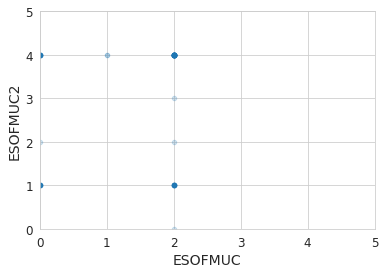

In [30]:
data_l.plot(kind="scatter", x="ESOFMUC", y="ESOFMUC2",
             alpha=0.2)
plt.axis([0, 5, 0, 5])
plt.show()

# Prepare the data for Machine Learning algorithms

In [31]:
train_data_set=train_set.drop("ESOFMUC2", axis=1)
train_data_set_verify=train_set['ESOFMUC2'].copy()
train_data_set

,SDA,SDA2,SDE,SDE2,VAR,VAR2,HIPO,HIPO2,ANEMIE,ANEMIE2,...,CONS2,DRE,DRE2,ULCER,ULCER2,BII,BII2,ALTE,ALTE2,ESOFMUC
49,0,1,1,1,1,1,1,1,1,1,...,1,1,0,0,0,1,2,1,1,1
70,1,1,1,1,1,1,1,1,1,1,...,1,1,0,0,0,1,2,0,1,0
68,1,1,1,0,1,1,1,1,1,1,...,1,1,0,0,0,1,2,1,1,2
15,0,0,1,1,1,1,1,1,1,1,...,1,1,0,0,0,1,2,1,1,0
39,0,1,1,1,1,1,0,0,1,1,...,1,1,0,0,0,1,2,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,0,1,1,1,1,1,0,1,1,1,...,1,1,0,0,0,1,2,1,1,2
71,1,1,1,1,1,1,1,1,1,1,...,1,1,0,0,0,1,2,1,1,0
14,1,1,1,1,0,1,1,1,1,1,...,1,1,0,0,0,1,2,1,1,2
92,1,1,1,1,1,1,1,1,1,1,...,1,1,0,0,0,1,2,1,1,0


In [32]:
train_data_set_verify

49    4
70    4
68    4
15    2
39    1
     ..
60    4
71    4
14    4
92    1
51    4
Name: ESOFMUC2, Length: 77, dtype: int64

In [33]:
sample_incomplete_rows = data_l[data_l.isnull().any(axis=1)].head()
print(sample_incomplete_rows)
#nu avem date incomplete, pentru ca le-am filtrat inainte

Empty DataFrame
Columns: [SDA, SDA2, SDE, SDE2, VAR, VAR2, HIPO, HIPO2, ANEMIE, ANEMIE2, AA, AA2, HDSI, HDSI2, GAS, GAS2, GASHP, GASHP2, ESOFAGITA, ESOFAGITA2, ANO, ANO2, BC, BC2, CEFALEE, CEFALEE2, CONS, CONS2, DRE, DRE2, ULCER, ULCER2, BII, BII2, ALTE, ALTE2, ESOFMUC, ESOFMUC2, SdaAndSda2, VarAndVar2, EsofAndEsof2, BcAndBc2]
Index: []

[0 rows x 42 columns]


In [34]:
from sklearn.preprocessing import FunctionTransformer

gas, gas2 = [
    list(data_l.columns).index(col)
    for col in ("GAS", "GAS2")]

def add_extra_features(X):
    gasAndGas2 = X[:, gas] * X[:, gas2]
    return np.c_[X, gasAndGas2]

attr_adder = FunctionTransformer(add_extra_features, validate=False)
data_l_extra_features = attr_adder.fit_transform(data_l.values)

In [35]:
data_l_extra_features

array([[1, 1, 0, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [0, 1, 1, ..., 1, 1, 0],
       [1, 1, 1, ..., 1, 1, 0],
       [1, 1, 1, ..., 0, 1, 1]])

In [36]:
data_l_extra_features = pd.DataFrame(
    data_l_extra_features,
    columns=list(data_l.columns)+["gasAndGas2Extra"])
data_l_extra_features

,SDA,SDA2,SDE,SDE2,VAR,VAR2,HIPO,HIPO2,ANEMIE,ANEMIE2,...,BII2,ALTE,ALTE2,ESOFMUC,ESOFMUC2,SdaAndSda2,VarAndVar2,EsofAndEsof2,BcAndBc2,gasAndGas2Extra
0,1,1,0,1,1,1,0,0,1,1,...,2,1,1,2,4,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,1,...,2,0,0,0,1,1,1,1,1,1
2,1,1,1,1,1,1,0,1,1,1,...,2,1,1,2,4,1,1,1,1,1
3,0,1,1,1,1,1,1,1,1,1,...,2,0,1,2,1,0,1,1,1,1
4,1,1,1,1,1,1,0,1,1,1,...,2,1,1,2,4,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,1,1,1,1,1,1,1,1,1,1,...,2,1,1,0,1,1,1,1,1,0
93,1,1,0,1,1,1,1,1,1,1,...,2,1,1,0,4,1,1,0,1,1
94,0,1,1,1,1,1,1,1,1,1,...,2,1,1,2,4,0,1,1,1,0
95,1,1,1,1,1,1,0,1,1,1,...,2,1,1,0,4,1,1,1,1,0


In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
try:
    from sklearn.impute import SimpleImputer # Scikit-Learn 0.20+
except ImportError:
    from sklearn.preprocessing import Imputer as SimpleImputer

full_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('attribs_adder', FunctionTransformer(add_extra_features, validate=False)),
        ('std_scaler', StandardScaler()),
    ])

data_l_tr = full_pipeline.fit_transform(data_l_extra_features)

In [38]:
data_l_tr

array([[ 0.55750409,  0.29981268, -2.25      , ...,  0.14509525,
         0.8738629 ,  0.8738629 ],
       [ 0.55750409,  0.29981268,  0.44444444, ...,  0.14509525,
         0.8738629 ,  0.8738629 ],
       [ 0.55750409,  0.29981268,  0.44444444, ...,  0.14509525,
         0.8738629 ,  0.8738629 ],
       ...,
       [-1.79370881,  0.29981268,  0.44444444, ...,  0.14509525,
        -1.14434427, -1.14434427],
       [ 0.55750409,  0.29981268,  0.44444444, ...,  0.14509525,
        -1.14434427, -1.14434427],
       [ 0.55750409,  0.29981268,  0.44444444, ...,  0.14509525,
         0.8738629 ,  0.8738629 ]])

In [39]:
data_l_tr.shape

(97, 44)

# Select and train some models 

In [40]:
train, test = train_test_split(data_l_extra_features, test_size=0.2, random_state=42)
print(len(train), "train +", len(test), "test")

77 train + 20 test


In [41]:
x=train.drop(["ESOFMUC2"], axis=1)
y=train["ESOFMUC2"].copy()

In [42]:
full_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('attribs_adder', FunctionTransformer(add_extra_features, validate=False)),
        ('std_scaler', StandardScaler()),
    ])

x_tr = full_pipeline.fit_transform(x)

Linear regression

In [43]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(x_tr, y)

LinearRegression()

In [44]:
print(x)
some_data = x.iloc[:7]
some_labels = y
some_data_prepared = full_pipeline.transform(some_data)

print("Predictions:", lin_reg.predict(some_data_prepared))
print("Predictions:", lin_reg.predict(x_tr))

    SDA  SDA2  SDE  SDE2  VAR  VAR2  HIPO  HIPO2  ANEMIE  ANEMIE2  ...  BII  \
49    0     1    1     1    1     1     1      1       1        1  ...    1   
70    1     1    1     1    1     1     1      1       1        1  ...    1   
68    1     1    1     0    1     1     1      1       1        1  ...    1   
15    0     0    1     1    1     1     1      1       1        1  ...    1   
39    0     1    1     1    1     1     0      0       1        1  ...    1   
..  ...   ...  ...   ...  ...   ...   ...    ...     ...      ...  ...  ...   
60    0     1    1     1    1     1     0      1       1        1  ...    1   
71    1     1    1     1    1     1     1      1       1        1  ...    1   
14    1     1    1     1    0     1     1      1       1        1  ...    1   
92    1     1    1     1    1     1     1      1       1        1  ...    1   
51    1     1    0     1    1     1     1      1       1        1  ...    1   

    BII2  ALTE  ALTE2  ESOFMUC  SdaAndSda2  VarAndV

In [45]:
print("Labels:", list(some_labels))

Labels: [4, 4, 4, 2, 1, 4, 4, 4, 4, 4, 4, 4, 1, 4, 4, 1, 1, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 1, 4, 1, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 4, 1, 4, 4, 4, 1, 4, 4, 1, 4, 2, 4, 4, 4, 1, 4, 4, 4, 1, 1, 4, 1, 4, 4, 4, 4, 4, 4, 1, 1, 0, 4, 4, 4, 1, 4]


In [46]:
some_data_prepared

array([[-1.74717818,  0.29070095,  0.40824829,  0.26352314,  0.26352314,
         0.11470787,  0.57235147,  0.40824829,  0.20134682,  0.11470787,
         0.        ,  0.11470787,  0.15471319,  0.        ,  0.26352314,
        -1.28653504,  0.3863337 ,  0.8660254 ,  0.16329932,  0.53229065,
         0.20134682,  0.16329932,  0.16329932,  0.16329932,  0.16329932,
         0.        ,  0.16329932,  0.11470787,  0.16329932,  0.        ,
        -0.11470787, -0.11470787,  0.16329932,  0.15471319,  0.45069391,
         0.36380344, -0.34836651, -1.48604621,  0.29070095,  0.53229065,
         0.16329932, -1.21814243, -1.21814243],
       [ 0.57235147,  0.29070095,  0.40824829,  0.26352314,  0.26352314,
         0.11470787,  0.57235147,  0.40824829,  0.20134682,  0.11470787,
         0.        ,  0.11470787,  0.15471319,  0.        ,  0.26352314,
         0.77728159,  0.3863337 , -1.15470054,  0.16329932, -1.87867287,
         0.20134682,  0.16329932,  0.16329932,  0.16329932, -6.12372436,
   

In [47]:
from sklearn.metrics import mean_squared_error

data_predictions = lin_reg.predict(x_tr)
lin_mse = mean_squared_error(y, data_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

1.0880710647164769

In [48]:
from sklearn.metrics import mean_absolute_error

lin_mae = mean_absolute_error(y, data_predictions)
lin_mae

0.8385881783612711

Decision Tree

In [49]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(x_tr, y)

DecisionTreeRegressor(random_state=42)

In [50]:
data_predictions = tree_reg.predict(x_tr)
tree_mse = mean_squared_error(y, data_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

0.4629100498862757

In [51]:
dx=x.copy()

In [52]:
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(solver='sgd', 
                    alpha=1e-5, 
                    hidden_layer_sizes=(2,2), 
                    random_state=1, 
                    verbose=True, 
                    max_iter=1400) #try 1400

In [53]:
clf.fit(x,y)

Iteration 1, loss = 2.80816352
Iteration 2, loss = 2.80368209
Iteration 3, loss = 2.79731976
Iteration 4, loss = 2.78929423
Iteration 5, loss = 2.77980643
Iteration 6, loss = 2.76906121
Iteration 7, loss = 2.75723862
Iteration 8, loss = 2.74452066
Iteration 9, loss = 2.73108045
Iteration 10, loss = 2.71696197
Iteration 11, loss = 2.70227182
Iteration 12, loss = 2.68710480
Iteration 13, loss = 2.67159056
Iteration 14, loss = 2.65580701
Iteration 15, loss = 2.63976967
Iteration 16, loss = 2.62353339
Iteration 17, loss = 2.60714601
Iteration 18, loss = 2.59064749
Iteration 19, loss = 2.57406363
Iteration 20, loss = 2.55742276
Iteration 21, loss = 2.54076353
Iteration 22, loss = 2.52410874
Iteration 23, loss = 2.50748832
Iteration 24, loss = 2.49102774
Iteration 25, loss = 2.47464015
Iteration 26, loss = 2.45831590
Iteration 27, loss = 2.44212006
Iteration 28, loss = 2.42602703
Iteration 29, loss = 2.41001074
Iteration 30, loss = 2.39407451
Iteration 31, loss = 2.37822049
Iteration 32, los

Iteration 373, loss = 0.78586420
Iteration 374, loss = 0.78556290
Iteration 375, loss = 0.78526649
Iteration 376, loss = 0.78497489
Iteration 377, loss = 0.78468805
Iteration 378, loss = 0.78440589
Iteration 379, loss = 0.78412835
Iteration 380, loss = 0.78385538
Iteration 381, loss = 0.78358691
Iteration 382, loss = 0.78332286
Iteration 383, loss = 0.78306319
Iteration 384, loss = 0.78280783
Iteration 385, loss = 0.78255672
Iteration 386, loss = 0.78230980
Iteration 387, loss = 0.78206700
Iteration 388, loss = 0.78182827
Iteration 389, loss = 0.78159354
Iteration 390, loss = 0.78136277
Iteration 391, loss = 0.78113588
Iteration 392, loss = 0.78091282
Iteration 393, loss = 0.78069354
Iteration 394, loss = 0.78047798
Iteration 395, loss = 0.78026607
Iteration 396, loss = 0.78005777
Iteration 397, loss = 0.77985302
Iteration 398, loss = 0.77965176
Iteration 399, loss = 0.77945394
Iteration 400, loss = 0.77925951
Iteration 401, loss = 0.77906841
Iteration 402, loss = 0.77888058
Iteration 

MLPClassifier(alpha=1e-05, hidden_layer_sizes=(2, 2), max_iter=1400,
              random_state=1, solver='sgd', verbose=True)

In [54]:
[coef.shape for coef in clf.coefs_]

[(42, 2), (2, 2), (2, 5)]

In [55]:
clf.coefs_

[array([[-0.06450472,  0.20838276],
        [-0.37381239, -0.03411665],
        [-0.2683526 , -0.25808442],
        [-0.23917674, -0.05808228],
        [-0.08370691,  0.11096038],
        [-0.06714345,  0.19057706],
        [-0.21789699,  0.34480276],
        [-0.35188927,  0.15812768],
        [-0.0685391 ,  0.11843352],
        [-0.27305638, -0.12957625],
        [ 0.22211446,  0.3458339 ],
        [-0.14525998,  0.19614983],
        [ 0.26305229,  0.41666167],
        [-0.30646498, -0.34043041],
        [-0.25131094,  0.37380584],
        [-0.30087103, -0.04537557],
        [ 0.33070896,  0.05201847],
        [ 0.13424588, -0.12475722],
        [ 0.13388867,  0.30922725],
        [-0.35677672,  0.25401998],
        [ 0.35358295,  0.24169291],
        [-0.16961745,  0.25468641],
        [-0.30050153,  0.03363948],
        [ 0.29430292, -0.08030332],
        [-0.16420289, -0.22802358],
        [-0.35497082,  0.13207872],
        [-0.22044131, -0.1225682 ],
        [-0.01368831, -0.272

In [56]:
from sklearn.preprocessing import StandardScaler  
scaler = StandardScaler()  
# Don't cheat - fit only on training data
scaler.fit(x)  
x = scaler.transform(x)  
x

array([[-1.74717818,  0.29070095,  0.40824829, ...,  0.53229065,
         0.16329932, -1.21814243],
       [ 0.57235147,  0.29070095,  0.40824829, ..., -1.87867287,
         0.16329932,  0.82092207],
       [ 0.57235147,  0.29070095,  0.40824829, ...,  0.53229065,
         0.16329932,  0.82092207],
       ...,
       [ 0.57235147,  0.29070095,  0.40824829, ...,  0.53229065,
         0.16329932,  0.82092207],
       [ 0.57235147,  0.29070095,  0.40824829, ...,  0.53229065,
         0.16329932, -1.21814243],
       [ 0.57235147,  0.29070095, -2.44948974, ...,  0.53229065,
         0.16329932, -1.21814243]])

In [57]:
clf.fit(x,y)

Iteration 1, loss = 2.99759186
Iteration 2, loss = 2.99067335
Iteration 3, loss = 2.98084130
Iteration 4, loss = 2.96842350
Iteration 5, loss = 2.95372157
Iteration 6, loss = 2.93701212
Iteration 7, loss = 2.91854787
Iteration 8, loss = 2.89855908
Iteration 9, loss = 2.87725486
Iteration 10, loss = 2.85482460
Iteration 11, loss = 2.83143940
Iteration 12, loss = 2.80725342
Iteration 13, loss = 2.78240522
Iteration 14, loss = 2.75701905
Iteration 15, loss = 2.73120602
Iteration 16, loss = 2.70506531
Iteration 17, loss = 2.67868522
Iteration 18, loss = 2.65214415
Iteration 19, loss = 2.62551160
Iteration 20, loss = 2.59884899
Iteration 21, loss = 2.57221047
Iteration 22, loss = 2.54564369
Iteration 23, loss = 2.51919040
Iteration 24, loss = 2.49288717
Iteration 25, loss = 2.46676586
Iteration 26, loss = 2.44085418
Iteration 27, loss = 2.41517615
Iteration 28, loss = 2.38975247
Iteration 29, loss = 2.36460097
Iteration 30, loss = 2.33973688
Iteration 31, loss = 2.31517316
Iteration 32, los

Iteration 261, loss = 0.86118340
Iteration 262, loss = 0.85995573
Iteration 263, loss = 0.85873976
Iteration 264, loss = 0.85753092
Iteration 265, loss = 0.85632994
Iteration 266, loss = 0.85513677
Iteration 267, loss = 0.85395307
Iteration 268, loss = 0.85277903
Iteration 269, loss = 0.85161585
Iteration 270, loss = 0.85045592
Iteration 271, loss = 0.84930583
Iteration 272, loss = 0.84816635
Iteration 273, loss = 0.84703547
Iteration 274, loss = 0.84591151
Iteration 275, loss = 0.84479640
Iteration 276, loss = 0.84368943
Iteration 277, loss = 0.84259163
Iteration 278, loss = 0.84150039
Iteration 279, loss = 0.84041805
Iteration 280, loss = 0.83934330
Iteration 281, loss = 0.83827822
Iteration 282, loss = 0.83721938
Iteration 283, loss = 0.83616794
Iteration 284, loss = 0.83512401
Iteration 285, loss = 0.83409274
Iteration 286, loss = 0.83306414
Iteration 287, loss = 0.83204451
Iteration 288, loss = 0.83103188
Iteration 289, loss = 0.83002590
Iteration 290, loss = 0.82903218
Iteration 

Iteration 520, loss = 0.71857961
Iteration 521, loss = 0.71836421
Iteration 522, loss = 0.71815210
Iteration 523, loss = 0.71793642
Iteration 524, loss = 0.71772971
Iteration 525, loss = 0.71751347
Iteration 526, loss = 0.71731317
Iteration 527, loss = 0.71709924
Iteration 528, loss = 0.71688942
Iteration 529, loss = 0.71668597
Iteration 530, loss = 0.71647623
Iteration 531, loss = 0.71627465
Iteration 532, loss = 0.71606895
Iteration 533, loss = 0.71586303
Iteration 534, loss = 0.71566548
Iteration 535, loss = 0.71546245
Iteration 536, loss = 0.71526032
Iteration 537, loss = 0.71506364
Iteration 538, loss = 0.71485944
Iteration 539, loss = 0.71466632
Iteration 540, loss = 0.71446713
Iteration 541, loss = 0.71426755
Iteration 542, loss = 0.71407385
Iteration 543, loss = 0.71387975
Iteration 544, loss = 0.71368504
Iteration 545, loss = 0.71349032
Iteration 546, loss = 0.71329671
Iteration 547, loss = 0.71310814
Iteration 548, loss = 0.71291570
Iteration 549, loss = 0.71272487
Iteration 

Iteration 855, loss = 0.66585585
Iteration 856, loss = 0.66573468
Iteration 857, loss = 0.66561896
Iteration 858, loss = 0.66549379
Iteration 859, loss = 0.66537736
Iteration 860, loss = 0.66525308
Iteration 861, loss = 0.66514210
Iteration 862, loss = 0.66501848
Iteration 863, loss = 0.66489959
Iteration 864, loss = 0.66477704
Iteration 865, loss = 0.66466719
Iteration 866, loss = 0.66456201
Iteration 867, loss = 0.66446771
Iteration 868, loss = 0.66435927
Iteration 869, loss = 0.66425097
Iteration 870, loss = 0.66413936
Iteration 871, loss = 0.66403144
Iteration 872, loss = 0.66391712
Iteration 873, loss = 0.66381235
Iteration 874, loss = 0.66370947
Iteration 875, loss = 0.66360313
Iteration 876, loss = 0.66349298
Iteration 877, loss = 0.66338800
Iteration 878, loss = 0.66328589
Iteration 879, loss = 0.66317287
Iteration 880, loss = 0.66307122
Iteration 881, loss = 0.66296556
Iteration 882, loss = 0.66286229
Iteration 883, loss = 0.66275441
Iteration 884, loss = 0.66265200
Iteration 

MLPClassifier(alpha=1e-05, hidden_layer_sizes=(2, 2), max_iter=1400,
              random_state=1, solver='sgd', verbose=True)

In [58]:
arr=dx.iloc[0].values
dx.iloc[0]

SDA                0
SDA2               1
SDE                1
SDE2               1
VAR                1
VAR2               1
HIPO               1
HIPO2              1
ANEMIE             1
ANEMIE2            1
AA                 0
AA2                1
HDSI               2
HDSI2              0
GAS                1
GAS2               0
GASHP              1
GASHP2             1
ESOFAGITA          1
ESOFAGITA2         1
ANO                1
ANO2               1
BC                 1
BC2                1
CEFALEE            1
CEFALEE2           0
CONS               1
CONS2              1
DRE                1
DRE2               0
ULCER              0
ULCER2             0
BII                1
BII2               2
ALTE               1
ALTE2              1
ESOFMUC            1
SdaAndSda2         0
VarAndVar2         1
EsofAndEsof2       1
BcAndBc2           1
gasAndGas2Extra    0
Name: 49, dtype: int64

In [59]:
clf.predict([ arr])

array([4])

# Fine-tune your model

In [60]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree_reg, x_tr, y,
                         scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

In [61]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(tree_rmse_scores)

Scores: [1.45773797 2.20794022 1.62018517 1.5411035  1.85404962 1.29903811
 2.47487373 2.04415543 1.96396101 2.54249596]
Mean: 1.90055407324809
Standard deviation: 0.4036015543330998


In [62]:
lin_scores = cross_val_score(lin_reg, x_tr, y,
                             scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores: [9.46776643e-01 3.10460704e+00 1.97964262e+00 1.83641832e+00
 3.83574685e+12 1.84789981e+13 2.27585869e+00 2.06552700e+00
 1.21959177e+00 1.83677387e+00]
Mean: 2231474497497.3086
Standard deviation: 5535264594164.567


Putem observa ca linear regression nu poate functiona bine pe acest set de date

In [63]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(n_estimators=10, random_state=42)
forest_reg.fit(x_tr, y)

RandomForestRegressor(n_estimators=10, random_state=42)

In [64]:
data_predictions = forest_reg.predict(x_tr)
forest_mse = mean_squared_error(y, data_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_rmse

0.7891410977411977

In [65]:
from sklearn.model_selection import cross_val_score

forest_scores = cross_val_score(forest_reg, x_tr, y,
                                scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

Scores: [1.07558124 2.1107056  1.35273132 1.53195137 1.78781225 1.29173938
 1.88828233 1.78775598 1.22765747 2.09119048]
Mean: 1.6145407416238773
Standard deviation: 0.3504365049102621


In [66]:
scores = cross_val_score(lin_reg, x_tr, y, scoring="neg_mean_squared_error", cv=10)
pd.Series(np.sqrt(-scores)).describe()

count    1.000000e+01
mean     2.231474e+12
std      5.834681e+12
min      9.467766e-01
25%      1.836507e+00
50%      2.022585e+00
75%      2.897420e+00
max      1.847900e+13
dtype: float64

In [67]:
from sklearn.svm import SVR

svm_reg = SVR(kernel="linear")
svm_reg.fit(x_tr, y)
data_pred = svm_reg.predict(x_tr)
svm_mse = mean_squared_error(y, data_pred)
svm_rmse = np.sqrt(svm_mse)
svm_rmse

1.2350641287903044

In [68]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    # try 12 (3×4) combinations of hyperparameters
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    # then try 6 (2×3) combinations with bootstrap set as False
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
  ]

forest_reg = RandomForestRegressor(random_state=42)
# train across 5 folds, that's a total of (12+6)*5=90 rounds of training 
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(x_tr, y)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [69]:
grid_search.best_params_

{'max_features': 8, 'n_estimators': 10}

In [70]:
grid_search.best_estimator_

RandomForestRegressor(max_features=8, n_estimators=10, random_state=42)

In [71]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

1.4763727134056932 {'max_features': 2, 'n_estimators': 3}
1.4438015064287704 {'max_features': 2, 'n_estimators': 10}
1.444151855755825 {'max_features': 2, 'n_estimators': 30}
1.5356954933020244 {'max_features': 4, 'n_estimators': 3}
1.4521588453316083 {'max_features': 4, 'n_estimators': 10}
1.4415549923323658 {'max_features': 4, 'n_estimators': 30}
1.6730850717783026 {'max_features': 6, 'n_estimators': 3}
1.4741066652244619 {'max_features': 6, 'n_estimators': 10}
1.4653053120915152 {'max_features': 6, 'n_estimators': 30}
1.506719286814654 {'max_features': 8, 'n_estimators': 3}
1.4211138256759066 {'max_features': 8, 'n_estimators': 10}
1.4472816297091244 {'max_features': 8, 'n_estimators': 30}
1.6478240422065926 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
1.5792818779432631 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
1.6898115169932308 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
1.5949497118509202 {'bootstrap': False, 'max_features': 3, 'n_e

In [72]:
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_n_estimators,param_bootstrap,params,split0_test_score,split1_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.006770,0.007663,0.000630,0.000064,2,3,NaN,"{'max_features': 2, 'n_estimators': 3}",-1.529514,-1.882812,...,-2.179676,0.839977,9,-0.680442,-0.911088,-0.905036,-0.691532,-0.657491,-0.769118,0.113994
1,0.007824,0.000333,0.001001,0.000038,2,10,NaN,"{'max_features': 2, 'n_estimators': 10}",-1.770212,-1.779905,...,-2.084563,0.572122,3,-0.601846,-0.567449,-0.619780,-0.468338,-0.538918,-0.559266,0.053336
2,0.021131,0.000339,0.001953,0.000060,2,30,NaN,"{'max_features': 2, 'n_estimators': 30}",-1.851014,-1.849483,...,-2.085575,0.435452,4,-0.533921,-0.525072,-0.523146,-0.383112,-0.450391,-0.483129,0.058336
3,0.002726,0.000087,0.000548,0.000012,4,3,NaN,"{'max_features': 4, 'n_estimators': 3}",-1.646267,-1.878906,...,-2.358361,0.849208,11,-0.730874,-0.808060,-0.809677,-0.899754,-0.717975,-0.793268,0.065405
4,0.007772,0.000344,0.000978,0.000057,4,10,NaN,"{'max_features': 4, 'n_estimators': 10}",-1.766974,-1.911909,...,-2.108765,0.555509,6,-0.628314,-0.584223,-0.598657,-0.508186,-0.600133,-0.583903,0.040464
5,0.020813,0.000264,0.001911,0.000059,4,30,NaN,"{'max_features': 4, 'n_estimators': 30}",-1.665124,-1.914517,...,-2.078081,0.518257,2,-0.511190,-0.516296,-0.562956,-0.425706,-0.465281,-0.496286,0.046926
6,0.002753,0.000132,0.000550,0.000003,6,3,NaN,"{'max_features': 6, 'n_estimators': 3}",-2.146701,-1.692274,...,-2.799214,0.895292,16,-0.876708,-0.916211,-1.016344,-0.778562,-0.662137,-0.849992,0.120966
7,0.007370,0.000137,0.000952,0.000056,6,10,NaN,"{'max_features': 6, 'n_estimators': 10}",-2.011742,-1.648915,...,-2.172990,0.459463,8,-0.611907,-0.621086,-0.649977,-0.506261,-0.564531,-0.590752,0.050402
8,0.020713,0.000255,0.001866,0.000045,6,30,NaN,"{'max_features': 6, 'n_estimators': 30}",-1.992149,-1.731592,...,-2.147120,0.350915,7,-0.518172,-0.526667,-0.528554,-0.430179,-0.496737,-0.500062,0.036721
9,0.002643,0.000049,0.000626,0.000112,8,3,NaN,"{'max_features': 8, 'n_estimators': 3}",-1.879340,-1.722656,...,-2.270203,0.800385,10,-0.747609,-0.850751,-0.956308,-0.693324,-0.687227,-0.787044,0.102967


In [73]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
        'n_estimators': randint(low=1, high=200),
        'max_features': randint(low=1, high=8),
    }

forest_reg = RandomForestRegressor(random_state=42)
rnd_search = RandomizedSearchCV(forest_reg, param_distributions=param_distribs,
                                n_iter=10, cv=5, scoring='neg_mean_squared_error', random_state=42)
rnd_search.fit(x_tr, y)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   param_distributions={'max_features': <scipy.stats._distn_infrastructure.rv_frozen object at 0x7fdc1f1c8a58>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_frozen object at 0x7fdc1f1c8b38>},
                   random_state=42, scoring='neg_mean_squared_error')

In [74]:
cvres = rnd_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

1.4844888666717837 {'max_features': 7, 'n_estimators': 180}
1.4423842842562407 {'max_features': 5, 'n_estimators': 15}
1.4652107144106201 {'max_features': 3, 'n_estimators': 72}
1.4615372603213805 {'max_features': 5, 'n_estimators': 21}
1.4718255040108466 {'max_features': 7, 'n_estimators': 122}
1.4644555788659672 {'max_features': 3, 'n_estimators': 75}
1.4645928942036313 {'max_features': 3, 'n_estimators': 88}
1.4620755248050092 {'max_features': 5, 'n_estimators': 100}
1.4786099499221037 {'max_features': 3, 'n_estimators': 150}
1.599323913147886 {'max_features': 5, 'n_estimators': 2}


In [75]:
feature_importances = grid_search.best_estimator_.feature_importances_
feature_importances

array([0.01509416, 0.04838516, 0.05500165, 0.03499989, 0.03399309,
       0.00371243, 0.0666505 , 0.01942213, 0.01435886, 0.00980215,
       0.        , 0.00933913, 0.01464246, 0.        , 0.05745478,
       0.00764865, 0.02245151, 0.07636782, 0.00117689, 0.02555385,
       0.0088146 , 0.00434199, 0.03345918, 0.00093348, 0.00724165,
       0.        , 0.00749863, 0.00478091, 0.00322044, 0.        ,
       0.00353067, 0.00765317, 0.01671292, 0.00789019, 0.05273796,
       0.05098608, 0.110305  , 0.04704534, 0.01104328, 0.03654636,
       0.00914659, 0.03868424, 0.02137219])

Evaluation on test set

In [76]:
x=test.drop(['ESOFMUC2'], axis=1)
y=test['ESOFMUC2'].copy()
#Am facut fit pe train set => vom testa pe test set

In [77]:
x

,SDA,SDA2,SDE,SDE2,VAR,VAR2,HIPO,HIPO2,ANEMIE,ANEMIE2,...,BII,BII2,ALTE,ALTE2,ESOFMUC,SdaAndSda2,VarAndVar2,EsofAndEsof2,BcAndBc2,gasAndGas2Extra
62,1,1,0,1,1,1,1,1,1,1,...,1,2,1,1,2,1,1,1,1,1
40,1,1,1,1,1,1,0,0,1,1,...,1,2,1,1,2,1,1,1,1,0
93,1,1,0,1,1,1,1,1,1,1,...,1,2,1,1,0,1,1,0,1,1
18,1,1,1,1,1,1,1,1,1,1,...,1,2,1,1,2,1,1,1,1,1
81,1,1,1,1,1,1,0,1,1,1,...,1,2,1,1,2,1,1,1,1,0
83,1,1,1,1,1,1,1,1,1,1,...,1,2,0,0,2,1,1,1,1,1
64,1,1,1,1,0,1,1,1,1,1,...,1,2,1,1,0,1,0,1,1,1
42,1,1,1,1,1,1,1,1,1,1,...,1,2,0,1,2,1,1,1,1,0
10,0,0,1,1,1,1,1,1,1,1,...,1,2,1,1,2,0,1,1,1,0
0,1,1,0,1,1,1,0,0,1,1,...,1,2,1,1,2,1,1,1,1,1


In [78]:
y

62    1
40    1
93    4
18    4
81    1
83    4
64    4
42    4
10    1
0     4
31    1
75    4
47    4
26    4
44    4
4     4
22    1
12    1
89    1
73    1
Name: ESOFMUC2, dtype: int64

In [79]:
x_tr_test=full_pipeline.transform(x)

In [80]:
final_model = grid_search.best_estimator_


X_test_prepared = full_pipeline.transform(x)
final_predictions = final_model.predict(X_test_prepared)

final_mse = mean_squared_error(y, final_predictions)
final_rmse = np.sqrt(final_mse)

In [81]:
final_rmse

1.931388484896769

In [82]:
from scipy import stats

confidence = 0.95
squared_errors = (final_predictions - y) ** 2
mean = squared_errors.mean()
m = len(squared_errors)

np.sqrt(stats.t.interval(confidence, m - 1,
                         loc=np.mean(squared_errors),
                         scale=stats.sem(squared_errors)))

array([1.4274879 , 2.32869089])

In [83]:
tscore = stats.t.ppf((1 + confidence) / 2, df=m - 1)
tmargin = tscore * squared_errors.std(ddof=1) / np.sqrt(m)
np.sqrt(mean - tmargin), np.sqrt(mean + tmargin)

(1.4274878994257443, 2.3286908889281013)

In [84]:
zscore = stats.norm.ppf((1 + confidence) / 2)
zmargin = zscore * squared_errors.std(ddof=1) / np.sqrt(m)
np.sqrt(mean - zmargin), np.sqrt(mean + zmargin)

(1.4646916869185649, 2.305472017061869)

In [85]:
data_pred = svm_reg.predict(x_tr_test)
data_pred

array([4.60961241, 3.68259419, 3.49996106, 4.29934918, 3.68381125,
       4.30017955, 3.5003818 , 4.29994546, 2.49989992, 2.06539068,
       2.68167073, 4.10041932, 4.09974903, 3.68391963, 4.30029998,
       3.68381125, 4.29982503, 4.09974903, 3.09836677, 3.70018518])

In [86]:
clf.predict(x)

array([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4])

In [87]:
clf.predict_proba(x)

array([[0.00355334, 0.13513467, 0.00598727, 0.00275066, 0.85257406],
       [0.01084303, 0.21915469, 0.01716726, 0.00931535, 0.74351966],
       [0.01533243, 0.24624519, 0.02344882, 0.01311199, 0.70186157],
       [0.00472673, 0.1544718 , 0.00786984, 0.00379154, 0.8291401 ],
       [0.00900642, 0.20535786, 0.01452079, 0.00775613, 0.76335879],
       [0.00403697, 0.14350491, 0.00676609, 0.00317495, 0.84251708],
       [0.00887066, 0.20425368, 0.01432303, 0.00764071, 0.76491192],
       [0.00504028, 0.15913853, 0.00836914, 0.00407589, 0.82337616],
       [0.00274706, 0.11955874, 0.00467816, 0.00206025, 0.87095579],
       [0.01232986, 0.22901808, 0.01927445, 0.01057488, 0.72880273],
       [0.00481707, 0.15583514, 0.00801384, 0.00387321, 0.82746073],
       [0.00943744, 0.20878055, 0.01514661, 0.00812242, 0.75851298],
       [0.00263549, 0.11720619, 0.0044958 , 0.00196658, 0.87369595],
       [0.00950176, 0.20928085, 0.01523973, 0.00817706, 0.75780059],
       [0.00490127, 0.15709192, 0.

In [88]:
tree_reg.predict(x_tr_test)

array([4., 4., 4., 2., 4., 2., 1., 4., 4., 0., 4., 2., 4., 4., 2., 4., 4.,
       4., 1., 4.])

In [89]:
y

62    1
40    1
93    4
18    4
81    1
83    4
64    4
42    4
10    1
0     4
31    1
75    4
47    4
26    4
44    4
4     4
22    1
12    1
89    1
73    1
Name: ESOFMUC2, dtype: int64

In [90]:
lin_reg.predict(x_tr_test)

array([4.16121898, 3.23860441, 2.64636508, 3.56314153, 3.0773574 ,
       3.84946934, 2.04840102, 3.94701055, 2.58312811, 2.31468821,
       2.65310324, 4.02345079, 3.84271686, 3.97663608, 3.89130098,
       3.0773574 , 3.9051789 , 3.84271686, 2.94158404, 3.01098137])

Dupa cum se poate observa, cel mai bine s-a descurcat tree_reg, atat din teste cat si din cross validation si grid search. Acesta fiind si modelul care va ramane ales ca fiind model de baza.